# Plant Disease Detection — Swin Transformer (PlantVillage)

Same 2-phase transfer-learning recipe as `train.ipynb`, backbone swapped to `microsoft/swin-tiny-patch4-window7-224` via Hugging Face `transformers` (TF weights).

Requires: `pip install transformers==4.57.6 tf-keras==2.20.0` (TF models were removed in transformers 5.x; tf-keras keeps Keras-2 API against TF 2.20).

In [1]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tf_keras as keras
import transformers
import pandas as pd
from transformers import TFSwinForImageClassification
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("tf_keras:", keras.__version__)
print("transformers:", transformers.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Available! Found {len(gpus)} GPU device(s):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("Note: Running on CPU.")

tf.random.set_seed(42)
np.random.seed(42)

# --- BUGFIX: transformers 4.57 TFSwin window_reverse ---
# Original computes windows-per-image as tf.cast(h*w/(ws*ws), int32).
# int32/int32 promotes to float64 and the division can land 1 ULP below
# the exact integer (196/49 -> 3.9999999999999996); the truncating cast
# then yields 3 instead of 4 and fit crashes with
# "Input to reshape ... requires a multiple of 980".
# Exact integer arithmetic fixes it:
import transformers.models.swin.modeling_tf_swin as _swin_tf

def _window_reverse_fixed(windows, window_size, height, width):
    x = tf.shape(windows)[0]
    y = (height * width) // (window_size * window_size)
    batch_size = tf.math.floordiv(x, y)
    windows = tf.reshape(
        windows, (batch_size, height // window_size, width // window_size, window_size, window_size, -1)
    )
    windows = tf.transpose(windows, (0, 1, 3, 2, 4, 5))
    return tf.reshape(windows, (batch_size, height, width, -1))

_swin_tf.window_reverse = _window_reverse_fixed

2026-09-13 06:32:43.924682: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-13 06:32:44.702264: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-13 06:32:47.311010: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/lenovo2004/plant_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProg

TensorFlow: 2.20.0
tf_keras: 2.20.0
transformers: 4.57.6
GPU Available! Found 1 GPU device(s):
  - /physical_device:GPU:0


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32
MODEL_ID = "microsoft/swin-tiny-patch4-window7-224"

DATA_DIR = "../../PlantVillage_28"
OUTPUT_DIR = "../models/swin"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_subdir = os.path.join(DATA_DIR, "train")
val_subdir = os.path.join(DATA_DIR, "val")

if os.path.exists(train_subdir) and os.path.exists(val_subdir):
    print(f"[INFO] Loading dataset from explicit train and val subfolders in '{DATA_DIR}'")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_subdir,
        labels="inferred",
        label_mode="int",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=42
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_subdir,
        labels="inferred",
        label_mode="int",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    class_names = train_ds.class_names
else:
    print(f"[INFO] Applying 80/20 train/val split on directory '{DATA_DIR}'")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="training",
        seed=42,
        labels="inferred",
        label_mode="int",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="validation",
        seed=42,
        labels="inferred",
        label_mode="int",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    class_names = train_ds.class_names

print(f"[INFO] Found {len(class_names)} classes.")
print(f"[INFO] Classes: {class_names}")

with open(os.path.join(OUTPUT_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

[INFO] Loading dataset from explicit train and val subfolders in '../../PlantVillage_28'
Found 30835 files belonging to 28 classes.
Found 7707 files belonging to 28 classes.
[INFO] Found 28 classes.
[INFO] Classes: ['Apple_cedar_rust', 'Apple_healthy', 'Apple_scab', 'Bell_pepper_bacterial_spot', 'Bell_pepper_healthy', 'Blueberry_healthy', 'Cherry_healthy', 'Corn_common_rust', 'Corn_gray_leaf_spot', 'Corn_northern_leaf_blight', 'Grape_black_rot', 'Grape_healthy', 'Peach_healthy', 'Potato_early_blight', 'Potato_late_blight', 'Raspberry_healthy', 'Soybean_healthy', 'Squash_powdery_mildew', 'Strawberry_healthy', 'Tomato_bacterial_spot', 'Tomato_early_blight', 'Tomato_healthy', 'Tomato_late_blight', 'Tomato_leaf_mold', 'Tomato_mosaic_virus', 'Tomato_septoria_leaf_spot', 'Tomato_two_spotted_spider_mite', 'Tomato_yellow_leaf_curl_virus']


In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class SwinClassifier(keras.Model):
    def __init__(self, swin_model, augment=False, **kwargs):
        super().__init__(**kwargs)

        self.swin = swin_model
        self.augment = augment

        if augment:
            self.augmentation = keras.Sequential([
                keras.layers.RandomFlip("horizontal_and_vertical"),
                keras.layers.RandomRotation(0.15),
                keras.layers.RandomZoom(0.15),
                keras.layers.RandomContrast(0.1),
            ], name="data_augmentation")

        self.rescale = keras.layers.Rescaling(1.0 / 255.0)

        self.normalization = keras.layers.Normalization(
            mean=IMAGENET_MEAN,
            variance=[s * s for s in IMAGENET_STD],
        )

    def call(self, inputs, training=False):
        x = inputs

        if self.augment:
            x = self.augmentation(x, training=training)

        x = self.rescale(x)
        x = self.normalization(x)

        x = tf.transpose(x, (0, 3, 1, 2))

        return self.swin(
            pixel_values=x,
            training=training
        ).logits


def create_swin_model(num_classes, augment=True):

    swin_model = TFSwinForImageClassification.from_pretrained(
        MODEL_ID,
        num_labels=num_classes,
        ignore_mismatched_sizes=True,
        use_safetensors=False,
    )

    swin_model.swin.trainable = False

    model = SwinClassifier(
        swin_model,
        augment=augment
    )

    return model, swin_model


num_classes = len(class_names)

model, swin_model = create_swin_model(
    num_classes,
    augment=True
)

model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)))

model.summary()

All model checkpoint layers were used when initializing TFSwinForImageClassification.

Some layers of TFSwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized: ['swin/encoder/layers.1/blocks.1/attention/self/relative_position_index:0', 'swin/encoder/layers.0/blocks.0/attention/self/relative_position_index:0', 'swin/encoder/layers.2/blocks.5/attention/self/relative_position_index:0', 'swin/encoder/layers.3/blocks.1/attention/self/relative_position_index:0', 'swin/encoder/layers.2/blocks.2/attention/self/relative_position_index:0', 'swin/encoder/layers.2/blocks.0/attention/self/relative_position_index:0', 'swin/encoder/layers.2/blocks.3/attention/self/relative_position_index:0', 'swin/encoder/layers.0/blocks.1/attention/self/relative_position_index:0', 'swin/encoder/layers.1/blocks.0/attention/self/relative_position_index:0', 'swin/encoder/layers.2/blocks.4/attention/self/relative_position_index:0', 's

Model: "swin_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 tf_swin_for_image_classifi  multiple                  27569698  
 cation_1 (TFSwinForImageCl                                      
 assification)                                                   
                                                                 
 data_augmentation (Sequent  (1, 224, 224, 3)          0         
 ial)                                                            
                                                                 
 rescaling (Rescaling)       multiple                  0         
                                                                 
 normalization (Normalizati  multiple                  0         
 on)                                                             
                                                                 
Total params: 27569698 (105.17 MB)
Trainable params

In [4]:
print("Swin encoder stages:", len(swin_model.swin.encoder.layers))

for i, layer in enumerate(swin_model.swin.encoder.layers):
    print(i, layer.name, layer.__class__.__name__)

Swin encoder stages: 4
0 layers.0 TFSwinStage
1 layers.1 TFSwinStage
2 layers.2 TFSwinStage
3 layers.3 TFSwinStage


In [5]:
EPOCHS_PHASE1 = 15
LR_PHASE1 = 1e-3

print("=" * 60)
print("PHASE 1: Feature Extraction Training (Base Model Frozen)")
print("=" * 60)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

callbacks_phase1 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, verbose=1),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "swin_phase1_best.h5"),
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
]

start_time = time.time()
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1
)
print(f"[INFO] Phase 1 completed in {time.time() - start_time:.2f} seconds.")

PHASE 1: Feature Extraction Training (Base Model Frozen)
Epoch 1/15


2026-09-10 09:06:15.286987: I external/local_xla/xla/service/service.cc:163] XLA service 0x7183e98d35a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-10 09:06:15.287027: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-09-10 09:06:15.409643: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  1/964 [..............................] - ETA: 11:44:17 - loss: 3.5680 - accuracy: 0.0625

I0000 00:00:1789031175.965189    1334 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


964/964 [==============================] - ETA: 0s - loss: 0.5463 - accuracy: 0.8668
Epoch 1: val_accuracy improved from -inf to 0.92695, saving model to ../models/swin/swin_phase1_best.h5
964/964 [==============================] - 664s 644ms/step - loss: 0.5463 - accuracy: 0.8668 - val_loss: 0.2677 - val_accuracy: 0.9269 - lr: 0.0010
Epoch 2/15
964/964 [==============================] - ETA: 0s - loss: 0.1888 - accuracy: 0.9502
Epoch 2: val_accuracy improved from 0.92695 to 0.94628, saving model to ../models/swin/swin_phase1_best.h5
964/964 [==============================] - 613s 634ms/step - loss: 0.1888 - accuracy: 0.9502 - val_loss: 0.1927 - val_accuracy: 0.9463 - lr: 0.0010
Epoch 3/15
964/964 [==============================] - ETA: 0s - loss: 0.1369 - accuracy: 0.9628
Epoch 3: val_accuracy improved from 0.94628 to 0.95757, saving model to ../models/swin/swin_phase1_best.h5
964/964 [==============================] - 610s 631ms/step - loss: 0.1369 - accuracy: 0.9628 - val_loss: 0.14

In [7]:
for i, stage in enumerate(swin_model.swin.encoder.layers):
    print(i, stage.name, "Trainable:", stage.trainable)

0 layers.0 Trainable: False
1 layers.1 Trainable: False
2 layers.2 Trainable: False
3 layers.3 Trainable: False


In [8]:
EPOCHS_PHASE2 = 15
LR_PHASE2 = 1e-5
UNFREEZE_STAGES = 1  # unfreeze the last Swin stage(s)


def unfreeze_swin_backbone(swin_model, unfreeze_stages=1):
    backbone = swin_model.swin
    # Parent must be set trainable FIRST — children flags are ignored
    # while the parent is frozen (otherwise phase 2 silently trains only the head).
    backbone.trainable = True
    backbone.embeddings.trainable = False
    for stage in backbone.encoder.layers[:-unfreeze_stages]:
        stage.trainable = False
    # the last N stage(s) + final layernorm stay trainable


print("=" * 60)
print("PHASE 2: Fine-Tuning Swin Transformer")
print("=" * 60)

# Rebuild deterministically from the Phase 1 HF checkpoint.
# Works both in-session and after a kernel restart.
swin_model = TFSwinForImageClassification.from_pretrained(PHASE1_HF_DIR)
model = SwinClassifier(swin_model, augment=True)
model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)))
print("[INFO] Loaded best Phase 1 weights from:", PHASE1_HF_DIR)

unfreeze_swin_backbone(swin_model, UNFREEZE_STAGES)

trainable_params = sum(int(tf.size(w)) for w in model.trainable_weights)
print(f"[INFO] Trainable parameters: {trainable_params:,}")
print("[INFO] Sanity check: should be ~14M (last stage + head), NOT ~3,845 (head only).")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, verbose=1),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "swin_phase2_best.h5"),
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
]

start_time = time.time()
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)
print(f"[INFO] Phase 2 completed in {time.time() - start_time:.2f} seconds.")

PHASE 2: Fine-Tuning Swin Transformer


All model checkpoint layers were used when initializing TFSwinForImageClassification.

All the layers of TFSwinForImageClassification were initialized from the model checkpoint at ../models/swin/swin_phase1_hf.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSwinForImageClassification for predictions without further training.


[INFO] Loaded best Phase 1 weights from: ../models/swin/swin_phase1_hf
[INFO] Trainable parameters: 14,206,924
[INFO] Sanity check: should be ~14M (last stage + head), NOT ~3,845 (head only).
Epoch 1/15


2026-09-11 07:26:04.363177: I external/local_xla/xla/service/service.cc:163] XLA service 0x7093ac3b5a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-11 07:26:04.363222: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-09-11 07:26:04.434656: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789111564.882464    9759 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


964/964 [==============================] - ETA: 0s - loss: 0.7860 - accuracy: 0.7944
Epoch 1: val_accuracy improved from -inf to 0.95212, saving model to ../models/swin/swin_phase2_best.h5
964/964 [==============================] - 716s 691ms/step - loss: 0.7860 - accuracy: 0.7944 - val_loss: 0.1530 - val_accuracy: 0.9521 - lr: 1.0000e-05
Epoch 2/15
964/964 [==============================] - ETA: 0s - loss: 0.1279 - accuracy: 0.9668
Epoch 2: val_accuracy improved from 0.95212 to 0.97366, saving model to ../models/swin/swin_phase2_best.h5
964/964 [==============================] - 676s 696ms/step - loss: 0.1279 - accuracy: 0.9668 - val_loss: 0.0825 - val_accuracy: 0.9737 - lr: 1.0000e-05
Epoch 3/15
964/964 [==============================] - ETA: 0s - loss: 0.0741 - accuracy: 0.9799
Epoch 3: val_accuracy improved from 0.97366 to 0.97587, saving model to ../models/swin/swin_phase2_best.h5
964/964 [==============================] - 655s 677ms/step - loss: 0.0741 - accuracy: 0.9799 - val_lo

In [9]:
 # Save the fine-tuned model in HF format for test.ipynb / deployment.
# EarlyStopping(restore_best_weights=True) already restored the best weights
# in memory, so no reload is needed.
model.swin.save_pretrained(os.path.join(OUTPUT_DIR, "plantvillage_swin"))
print("[SUCCESS] HF-format model saved to:", os.path.join(OUTPUT_DIR, "plantvillage_swin"))

[SUCCESS] HF-format model saved to: ../models/swin/plantvillage_swin


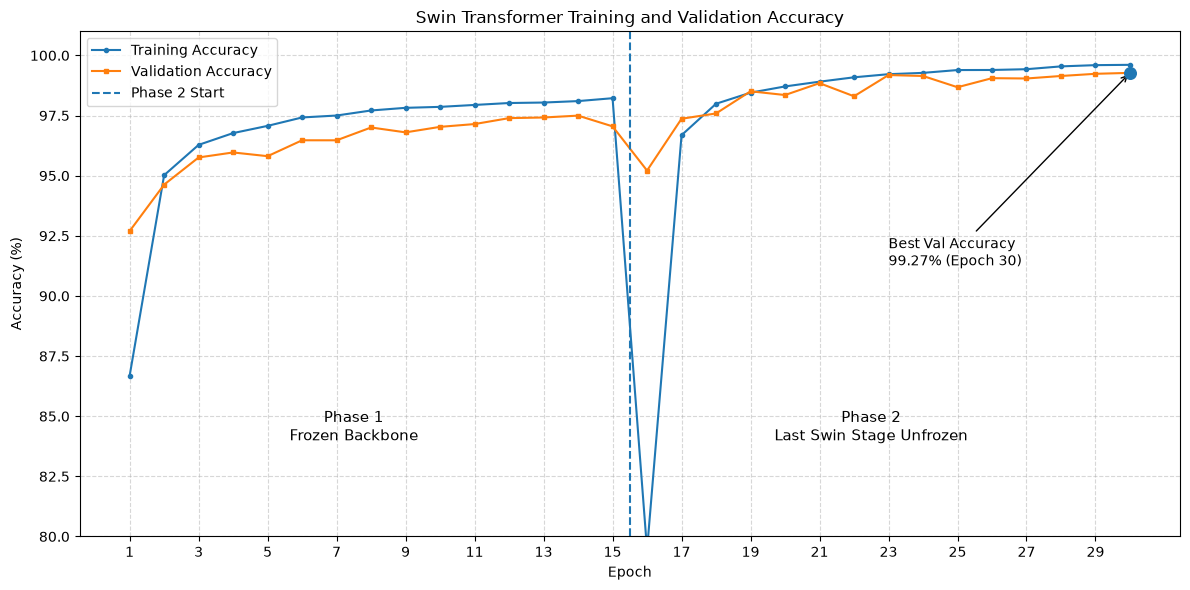

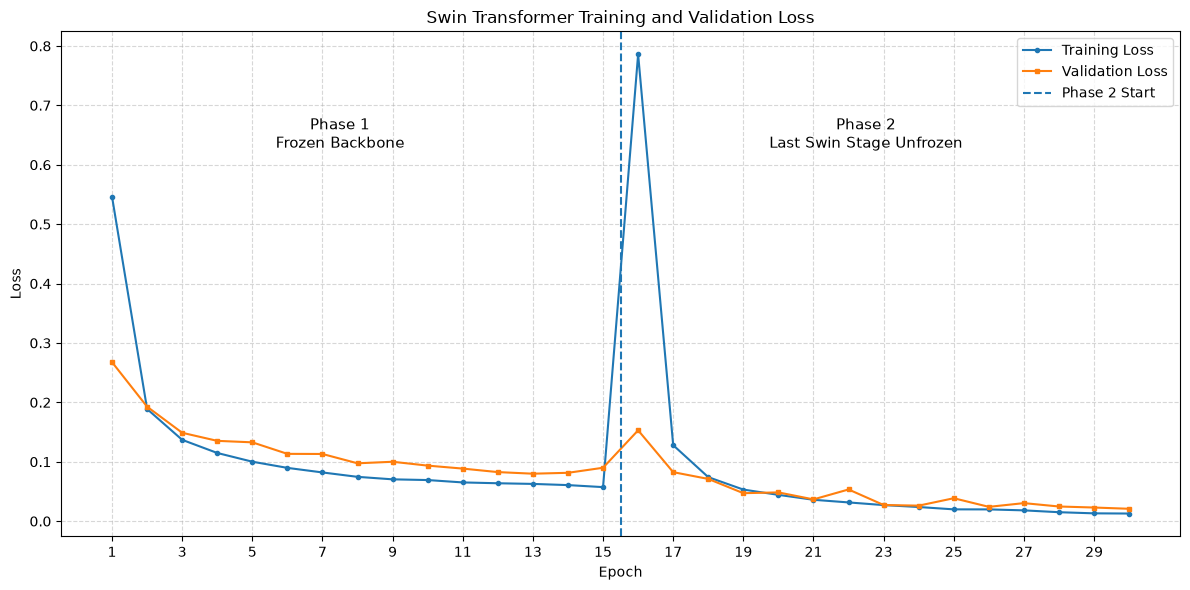

SWIN TRANSFORMER — COMBINED TRAINING RESULTS
Phase 1 Epochs              : 15
Phase 2 Epochs              : 15
Total Epochs                : 30

Best Phase 1 Val Accuracy   : 97.496% (Epoch 14)
Best Phase 2 Val Accuracy   : 99.273% (Phase 2 Epoch 15)
Overall Best Val Accuracy   : 99.273% (Overall Epoch 30)

Improvement Phase 1 → Phase 2: 1.777 percentage points

Accuracy Plot Saved To      : ../models/swin/plots/swin_combined_accuracy.png
Loss Plot Saved To          : ../models/swin/plots/swin_combined_loss.png


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PHASE 1 — EXACT RECORDED RESULTS
# ============================================================

phase1_acc = [
    0.8668, 0.9502, 0.9628, 0.9677, 0.9707,
    0.9742, 0.9750, 0.9771, 0.9782, 0.9786,
    0.9794, 0.9802, 0.9804, 0.9810, 0.9822
]

phase1_val_acc = [
    0.92695, 0.94628, 0.95757, 0.95965, 0.95810,
    0.96471, 0.96470, 0.97003, 0.96800, 0.97029,
    0.97145, 0.97392, 0.97418, 0.97496, 0.97050
]

phase1_loss = [
    0.5463, 0.1888, 0.1369, 0.1148, 0.1001,
    0.0897, 0.0820, 0.0746, 0.0704, 0.0692,
    0.0652, 0.0638, 0.0627, 0.0607, 0.0573
]

phase1_val_loss = [
    0.2677, 0.1927, 0.1488, 0.1352, 0.1327,
    0.1133, 0.1131, 0.0974, 0.1000, 0.0935,
    0.0885, 0.0826, 0.0799, 0.0814, 0.0899
]


# ============================================================
# PHASE 2 — FROM history_phase2
# ============================================================

phase2_acc = history_phase2.history["accuracy"]
phase2_val_acc = history_phase2.history["val_accuracy"]

phase2_loss = history_phase2.history["loss"]
phase2_val_loss = history_phase2.history["val_loss"]


# ============================================================
# COMBINE PHASE 1 + PHASE 2
# ============================================================

combined_acc = phase1_acc + phase2_acc
combined_val_acc = phase1_val_acc + phase2_val_acc

combined_loss = phase1_loss + phase2_loss
combined_val_loss = phase1_val_loss + phase2_val_loss

epochs = range(1, len(combined_acc) + 1)

phase1_end = len(phase1_acc)
phase2_start = phase1_end + 1


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

plot_dir = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(plot_dir, exist_ok=True)


# ============================================================
# 1. COMBINED ACCURACY CURVE
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    epochs,
    np.array(combined_acc) * 100,
    label="Training Accuracy",
    marker="o",
    markersize=3
)

plt.plot(
    epochs,
    np.array(combined_val_acc) * 100,
    label="Validation Accuracy",
    marker="s",
    markersize=3
)

# Phase separation
plt.axvline(
    x=phase1_end + 0.5,
    linestyle="--",
    linewidth=1.5,
    label="Phase 2 Start"
)

plt.text(
    7.5,
    84,
    "Phase 1\nFrozen Backbone",
    ha="center",
    fontsize=11
)

plt.text(
    22.5,
    84,
    "Phase 2\nLast Swin Stage Unfrozen",
    ha="center",
    fontsize=11
)

# Best validation accuracy
best_epoch = np.argmax(combined_val_acc) + 1
best_val_acc = max(combined_val_acc)

plt.scatter(
    best_epoch,
    best_val_acc * 100,
    s=70,
    zorder=5
)

plt.annotate(
    f"Best Val Accuracy\n{best_val_acc * 100:.2f}% (Epoch {best_epoch})",
    xy=(best_epoch, best_val_acc * 100),
    xytext=(best_epoch - 7, best_val_acc * 100 - 8),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.title("Swin Transformer Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, len(combined_acc) + 1, 2))
plt.ylim(80, 101)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

accuracy_path = os.path.join(
    plot_dir,
    "swin_combined_accuracy.png"
)

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 2. COMBINED LOSS CURVE
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    epochs,
    combined_loss,
    label="Training Loss",
    marker="o",
    markersize=3
)

plt.plot(
    epochs,
    combined_val_loss,
    label="Validation Loss",
    marker="s",
    markersize=3
)

# Phase separation
plt.axvline(
    x=phase1_end + 0.5,
    linestyle="--",
    linewidth=1.5,
    label="Phase 2 Start"
)

plt.text(
    7.5,
    max(combined_loss) * 0.80,
    "Phase 1\nFrozen Backbone",
    ha="center",
    fontsize=11
)

plt.text(
    22.5,
    max(combined_loss) * 0.80,
    "Phase 2\nLast Swin Stage Unfrozen",
    ha="center",
    fontsize=11
)

plt.title("Swin Transformer Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, len(combined_loss) + 1, 2))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

loss_path = os.path.join(
    plot_dir,
    "swin_combined_loss.png"
)

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL RESULTS
# ============================================================

print("=" * 70)
print("SWIN TRANSFORMER — COMBINED TRAINING RESULTS")
print("=" * 70)

print(f"Phase 1 Epochs              : {len(phase1_acc)}")
print(f"Phase 2 Epochs              : {len(phase2_acc)}")
print(f"Total Epochs                : {len(combined_acc)}")

print()

print(
    f"Best Phase 1 Val Accuracy   : "
    f"{max(phase1_val_acc) * 100:.3f}% "
    f"(Epoch {np.argmax(phase1_val_acc) + 1})"
)

print(
    f"Best Phase 2 Val Accuracy   : "
    f"{max(phase2_val_acc) * 100:.3f}% "
    f"(Phase 2 Epoch {np.argmax(phase2_val_acc) + 1})"
)

print(
    f"Overall Best Val Accuracy   : "
    f"{best_val_acc * 100:.3f}% "
    f"(Overall Epoch {best_epoch})"
)

print()

print(
    f"Improvement Phase 1 → Phase 2: "
    f"{(max(phase2_val_acc) - max(phase1_val_acc)) * 100:.3f} "
    f"percentage points"
)

print()

print(f"Accuracy Plot Saved To      : {accuracy_path}")
print(f"Loss Plot Saved To          : {loss_path}")

print("=" * 70)

VALIDATION DATASET EVALUATION
241/241 [==============================] - 122s 474ms/step - loss: 0.0208 - accuracy: 0.9927

[RESULT] Validation Loss: 0.0208
[RESULT] Validation Accuracy: 0.9927
[RESULT] Validation Accuracy (%): 99.27%

[INFO] Generating predictions...


2026-09-11 10:37:18.214197: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[INFO] Total validation samples: 7707

CLASSIFICATION REPORT
                                precision    recall  f1-score   support

              Apple_cedar_rust     1.0000    1.0000    1.0000        55
                 Apple_healthy     1.0000    0.9878    0.9939       329
                    Apple_scab     0.9921    1.0000    0.9960       126
    Bell_pepper_bacterial_spot     0.9950    1.0000    0.9975       200
           Bell_pepper_healthy     0.9966    1.0000    0.9983       295
             Blueberry_healthy     1.0000    1.0000    1.0000       300
                Cherry_healthy     0.9713    0.9941    0.9826       170
              Corn_common_rust     0.9958    0.9958    0.9958       239
           Corn_gray_leaf_spot     0.9700    0.9417    0.9557       103
     Corn_northern_leaf_blight     0.9650    0.9797    0.9723       197
               Grape_black_rot     1.0000    1.0000    1.0000       236
                 Grape_healthy     1.0000    1.0000    1.0000        84
  

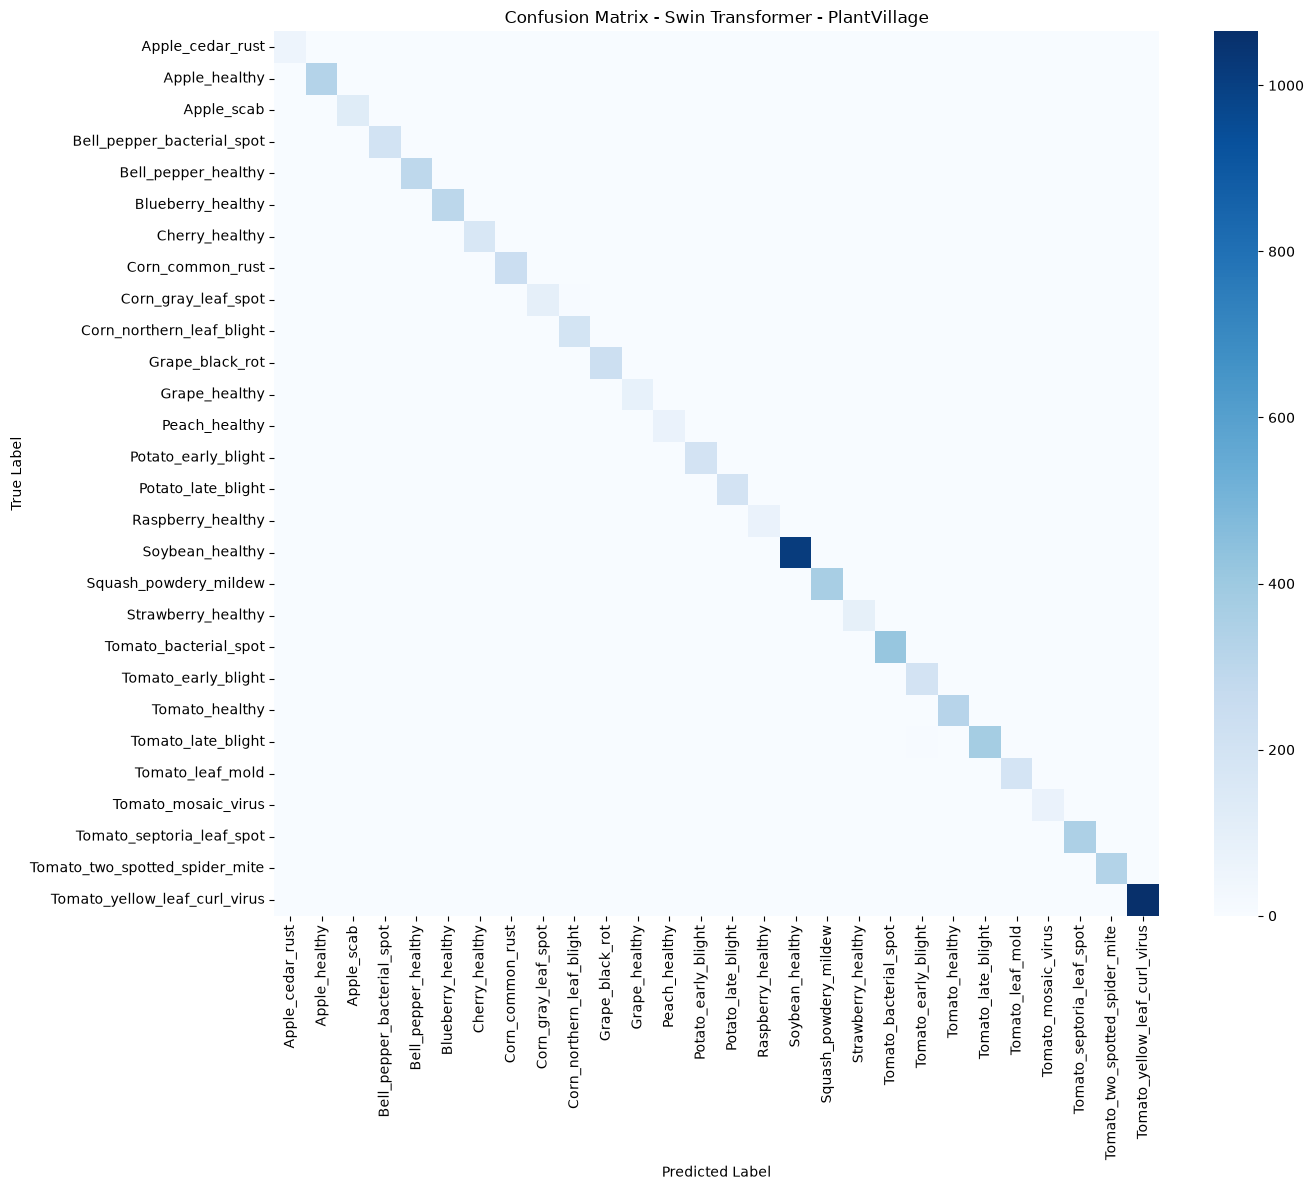

[SUCCESS] Confusion matrix saved to:
../models/swin/confusion_matrix.png

EVALUATION COMPLETE
Validation Samples : 7707
Validation Loss    : 0.0208
Validation Accuracy: 99.27%
Correct Predictions: 7651
Incorrect Predictions: 56


In [13]:
# ============================================================
# VALIDATION EVALUATION: REPORT + CONFUSION MATRIX
# ============================================================

print("=" * 60)
print("VALIDATION DATASET EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Evaluate model
# ------------------------------------------------------------

val_loss_value, val_accuracy_value = model.evaluate(
    val_ds,
    verbose=1
)

print(f"\n[RESULT] Validation Loss: {val_loss_value:.4f}")
print(f"[RESULT] Validation Accuracy: {val_accuracy_value:.4f}")
print(
    f"[RESULT] Validation Accuracy (%): "
    f"{val_accuracy_value * 100:.2f}%"
)


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

print("\n[INFO] Generating predictions...")

y_true = []
y_pred = []

for images, labels in val_ds:

    logits = model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        logits,
        axis=1
    )

    y_pred.extend(predictions)
    y_true.extend(labels.numpy())


y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    f"[INFO] Total validation samples: "
    f"{len(y_true)}"
)


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)


# Save TXT report
report_path = os.path.join(
    OUTPUT_DIR,
    "classification_report.txt"
)

with open(report_path, "w") as f:

    f.write(
        "Plant Disease Detection - Swin Transformer\n"
    )

    f.write(
        "PlantVillage Validation Classification Report\n\n"
    )

    f.write(
        f"Validation Accuracy: "
        f"{val_accuracy_value * 100:.2f}%\n\n"
    )

    f.write(report)


print(
    f"[SUCCESS] Classification report saved to:\n"
    f"{report_path}"
)


# ------------------------------------------------------------
# Classification Report CSV
# ------------------------------------------------------------

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_csv_path = os.path.join(
    OUTPUT_DIR,
    "classification_report.csv"
)

report_df.to_csv(
    report_csv_path
)

print(
    f"[SUCCESS] Classification CSV saved to:\n"
    f"{report_csv_path}"
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names))
)

print(
    f"[INFO] Confusion Matrix Shape: {cm.shape}"
)


plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - Swin Transformer - PlantVillage"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()


cm_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"[SUCCESS] Confusion matrix saved to:\n"
    f"{cm_path}"
)


# ------------------------------------------------------------
# Final Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EVALUATION COMPLETE")
print("=" * 60)

print(
    f"Validation Samples : {len(y_true)}"
)

print(
    f"Validation Loss    : {val_loss_value:.4f}"
)

print(
    f"Validation Accuracy: "
    f"{val_accuracy_value * 100:.2f}%"
)

print(
    f"Correct Predictions: "
    f"{np.sum(y_true == y_pred)}"
)

print(
    f"Incorrect Predictions: "
    f"{np.sum(y_true != y_pred)}"
)

print("=" * 60)

## PlantDoc Fine-Tuning
Transfer the PlantVillage-trained Swin to PlantDoc (same flow as train.ipynb cells 10-13).

In [11]:
PLANTDOC_DIR = "../../PlantDoc"
OUTPUT_DIR = "../models/swin"
IMG_SIZE = 224
BATCH_SIZE = 32
PLANTDOC_TRAIN = os.path.join(PLANTDOC_DIR, "train")
PLANTVILLAGE_SWIN_DIR = os.path.join(OUTPUT_DIR, "plantvillage_swin")

train_ds = tf.keras.utils.image_dataset_from_directory(
    PLANTDOC_TRAIN,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    PLANTDOC_TRAIN,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("\nNumber of classes:", num_classes)
print("Classes:")
for i, name in enumerate(class_names):
    print(i, name)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 2670 files belonging to 28 classes.
Using 2136 files for training.
Found 2670 files belonging to 28 classes.
Using 534 files for validation.

Number of classes: 28
Classes:
0 Apple_cedar_rust
1 Apple_healthy
2 Apple_scab
3 Bell_pepper_bacterial_spot
4 Bell_pepper_healthy
5 Blueberry_healthy
6 Cherry_healthy
7 Corn_common_rust
8 Corn_gray_leaf_spot
9 Corn_northern_leaf_blight
10 Grape_black_rot
11 Grape_healthy
12 Peach_healthy
13 Potato_early_blight
14 Potato_late_blight
15 Raspberry_healthy
16 Soybean_healthy
17 Squash_powdery_mildew
18 Strawberry_healthy
19 Tomato_bacterial_spot
20 Tomato_early_blight
21 Tomato_healthy
22 Tomato_late_blight
23 Tomato_leaf_mold
24 Tomato_mosaic_virus
25 Tomato_septoria_leaf_spot
26 Tomato_two_spotted_spider_mite
27 Tomato_yellow_leaf_curl_virus


In [9]:
print("=" * 60)
print("PLANTDOC: One-Shot Fine-Tuning (Last Swin Stage + Head)")
print("=" * 60)

# Load the PlantVillage-trained Swin, adapt the head to PlantDoc classes
swin_model = TFSwinForImageClassification.from_pretrained(
    PLANTVILLAGE_SWIN_DIR,
    num_labels=num_classes,
    ignore_mismatched_sizes=True,  # re-initializes the head for PlantDoc classes
)

# Unfreeze the last Swin stage + final layernorm; keep the rest frozen.
# (Parent must be set trainable FIRST — children flags are ignored while
# the parent is frozen, otherwise only the head trains.)
backbone = swin_model.swin
backbone.trainable = True
backbone.embeddings.trainable = False
for stage in backbone.encoder.layers[:-1]:
    stage.trainable = False

model = SwinClassifier(swin_model, augment=True)
model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)))

trainable_params = sum(int(tf.size(w)) for w in model.trainable_weights)
print(f"[INFO] Trainable parameters: {trainable_params:,}")
print("[INFO] Sanity check: should be ~14M (last stage + head), NOT ~3,845 (head only).")

# Head is freshly initialized while the backbone is already trained, so the LR
# sits between the old two-phase values (1e-4 head-only / 1e-5 backbone-only).
# Knob: lower it if val_loss spikes early, raise it if the head learns too slowly.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

callbacks_pd = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    )
]

start_time = time.time()
history_pd = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_pd
)
print(f"[INFO] PlantDoc fine-tuning completed in {time.time() - start_time:.2f} seconds.")

# Save final HF-format PlantDoc model (best weights already restored by EarlyStopping)
model.swin.save_pretrained(os.path.join(OUTPUT_DIR, "plantdoc_swin"))
print("[SUCCESS] HF-format PlantDoc model saved to:", os.path.join(OUTPUT_DIR, "plantdoc_swin"))

PLANTDOC: One-Shot Fine-Tuning (Last Swin Stage + Head)


All model checkpoint layers were used when initializing TFSwinForImageClassification.

All the layers of TFSwinForImageClassification were initialized from the model checkpoint at ../models/swin/plantvillage_swin.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSwinForImageClassification for predictions without further training.


[INFO] Trainable parameters: 14,206,924
[INFO] Sanity check: should be ~14M (last stage + head), NOT ~3,845 (head only).
Epoch 1/20


2026-09-13 07:07:51.535317: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


67/67 [==============================] - 129s 939ms/step - loss: 2.3056 - accuracy: 0.4007 - val_loss: 1.8243 - val_accuracy: 0.4944 - lr: 3.0000e-05
Epoch 2/20


2026-09-13 07:09:02.194951: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


67/67 [==============================] - 53s 738ms/step - loss: 1.4647 - accuracy: 0.5632 - val_loss: 1.5480 - val_accuracy: 0.5730 - lr: 3.0000e-05
Epoch 3/20
67/67 [==============================] - 47s 671ms/step - loss: 1.1151 - accuracy: 0.6550 - val_loss: 1.2508 - val_accuracy: 0.6517 - lr: 3.0000e-05
Epoch 4/20
67/67 [==============================] - 47s 675ms/step - loss: 0.9198 - accuracy: 0.6994 - val_loss: 1.1517 - val_accuracy: 0.6648 - lr: 3.0000e-05
Epoch 5/20
67/67 [==============================] - 60s 865ms/step - loss: 0.7659 - accuracy: 0.7491 - val_loss: 1.0871 - val_accuracy: 0.6779 - lr: 3.0000e-05
Epoch 6/20
67/67 [==============================] - 47s 678ms/step - loss: 0.6358 - accuracy: 0.7968 - val_loss: 1.0488 - val_accuracy: 0.6891 - lr: 3.0000e-05
Epoch 7/20
67/67 [==============================] - 47s 670ms/step - loss: 0.5443 - accuracy: 0.8296 - val_loss: 0.8816 - val_accuracy: 0.7266 - lr: 3.0000e-05
Epoch 8/20
67/67 [==============================] -

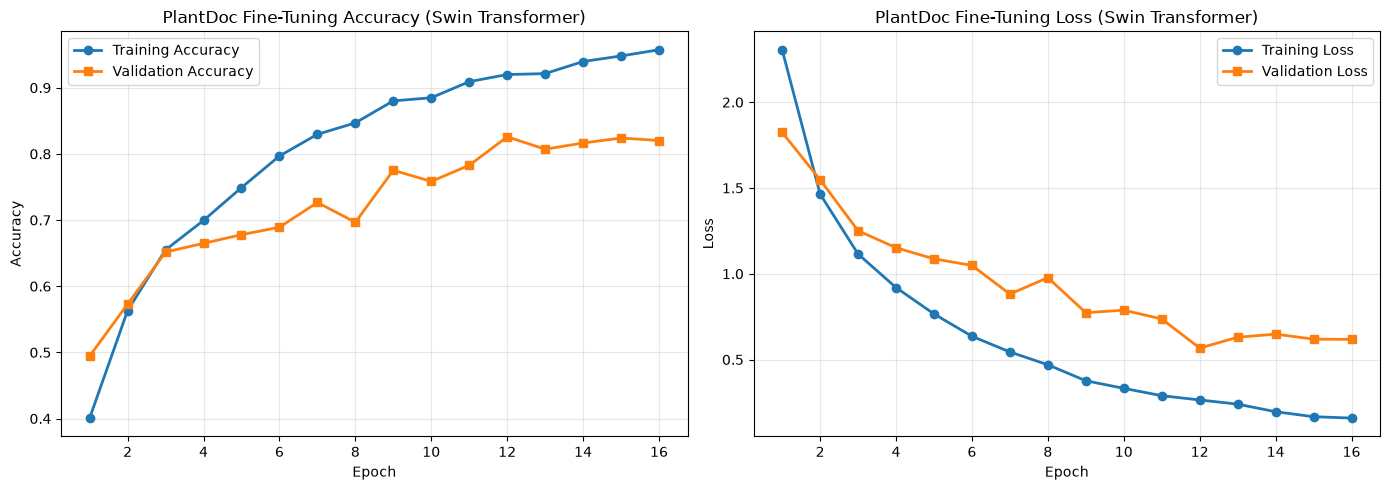

Training curves saved to: ../models/swin/plantdoc_swin_training_curves.png


In [12]:
import os
import matplotlib.pyplot as plt

# ============================================================
# PLANTDOC FINE-TUNING CURVES — SWIN TRANSFORMER
# ============================================================

# Extract training history
acc = history_pd.history["accuracy"]
val_acc = history_pd.history["val_accuracy"]
loss = history_pd.history["loss"]
val_loss = history_pd.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plot training curves
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    acc,
    label="Training Accuracy",
    marker="o",
    linewidth=2
)

plt.plot(
    epochs_range,
    val_acc,
    label="Validation Accuracy",
    marker="s",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PlantDoc Fine-Tuning Accuracy (Swin Transformer)")
plt.legend()
plt.grid(alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    loss,
    label="Training Loss",
    marker="o",
    linewidth=2
)

plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss",
    marker="s",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PlantDoc Fine-Tuning Loss (Swin Transformer)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Save figure
curve_path = os.path.join(
    OUTPUT_DIR,
    "plantdoc_swin_training_curves.png"
)

plt.savefig(
    curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Training curves saved to: {curve_path}")